<a href="https://colab.research.google.com/github/moise97/Extract_-_Structure_Data_from_SDFs_pharmaceutical_documentation/blob/main/OCR_Engine_Comparison_Report_%E2%80%94_Pharmaceutical_PDF_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# CELL 1: Install All OCR Dependencies
# ============================================
#
# WHAT WE'RE DOING:
#   Installing all three OCR engines and their dependencies.
#
# THREE ENGINES:
#   1. Tesseract  — Classic rule-based OCR (fast, lightweight)
#   2. PaddleOCR  — Deep learning OCR by Baidu (great for structured docs)
#   3. EasyOCR    — Deep learning OCR, beginner-friendly (good with varied fonts)
#
# ⚠️  After this cell finishes:
#       Runtime → Restart session → then START from CELL 2
# ============================================

# --- System tools ---
!apt-get install -y tesseract-ocr poppler-utils libgl1

# --- Python libraries ---
!pip install pytesseract easyocr pdf2image opencv-python-headless Pillow matplotlib

# --- PaddleOCR (pinned versions to avoid breakage) ---
!pip install paddlepaddle==2.6.2
!pip install paddleocr==2.9.1

print("\n" + "=" * 50)
print("✅ All dependencies installed!")
print("=" * 50)
print("\n⚠️  Go to Runtime → Restart session, then run CELL 2.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgl1 is already the newest version (1.4.0-1).
tesseract-ocr is already the newest version (4.1.1-2.1build1).
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.

✅ All dependencies installed!

⚠️  Go to Runtime → Restart session, then run CELL 2.


In [2]:
# ============================================
# CELL 2: Upload Your Document
# ============================================
#
# WHAT WE'RE DOING:
#   Uploading the label/document you want to OCR.
#   We support both PDF and image files (JPG, PNG, TIFF).
#
# HOW IT WORKS:
#   google.colab.files.upload() opens a file picker in your browser.
#   We then detect the file type and convert PDFs to images automatically,
#   because all three OCR engines work on images, not raw PDFs.
#
# OUTPUT:
#   A list called `images` — each item is one page as a PIL Image object.
# ============================================

import os
from google.colab import files
from PIL import Image
from pdf2image import convert_from_bytes
import io

print("📂 Please upload your PDF or image file...")
uploaded = files.upload()

# --- Grab the uploaded filename ---
filename = list(uploaded.keys())[0]
file_bytes = uploaded[filename]
ext = os.path.splitext(filename)[1].lower()

print(f"\n✅ Uploaded: {filename}  (type: {ext})")

# --- Convert to list of PIL images ---
images = []

if ext == ".pdf":
    print("📄 PDF detected — converting pages to images...")
    pil_images = convert_from_bytes(file_bytes, dpi=300)
    images = pil_images
    print(f"   → {len(images)} page(s) found")

elif ext in [".jpg", ".jpeg", ".png", ".tiff", ".tif", ".bmp"]:
    print("🖼️  Image detected — loading directly...")
    img = Image.open(io.BytesIO(file_bytes)).convert("RGB")
    images = [img]
    print(f"   → Image size: {img.size}")

else:
    raise ValueError(f"❌ Unsupported file type: {ext}. Use PDF, JPG, or PNG.")

print(f"\n✅ Ready! {len(images)} image(s) loaded for OCR.")

📂 Please upload your PDF or image file...


Saving pharmaceutical-sdf-page3-certificate-quality.pdf to pharmaceutical-sdf-page3-certificate-quality (1).pdf

✅ Uploaded: pharmaceutical-sdf-page3-certificate-quality (1).pdf  (type: .pdf)
📄 PDF detected — converting pages to images...
   → 1 page(s) found

✅ Ready! 1 image(s) loaded for OCR.


/tmp/ipykernel_10528/4259808388.py:28: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10528/4259808388.py:29: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.savefig("document_preview.png", bbox_inches="tight", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


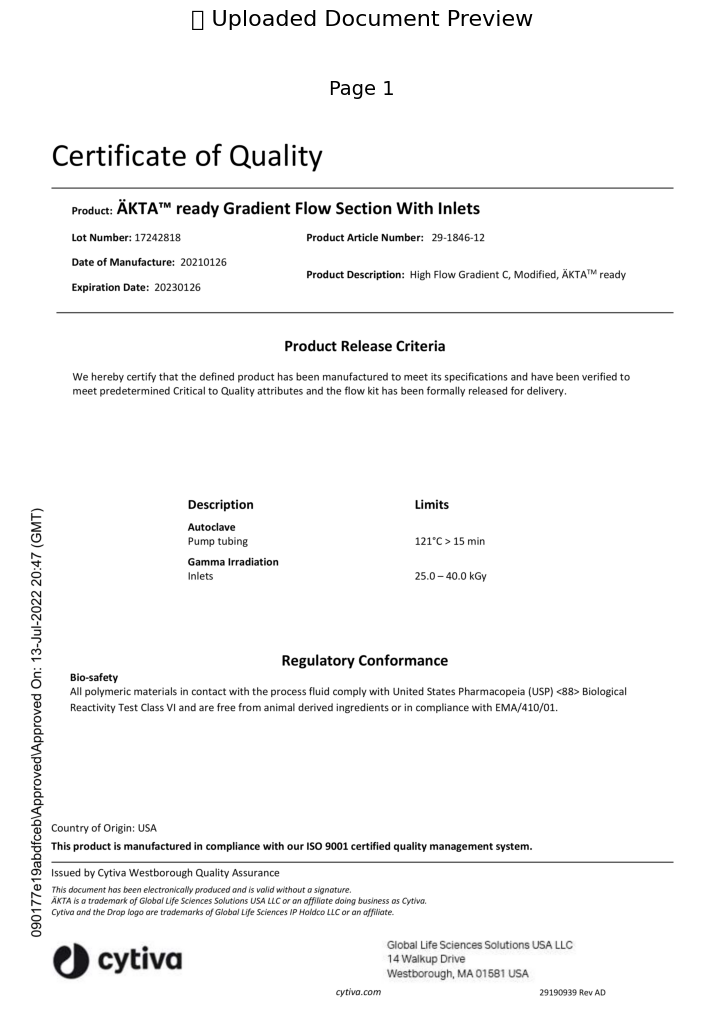

✅ Preview saved as document_preview.png


In [3]:
# ============================================
# CELL 3: Preview Your Document Pages
# ============================================
#
# WHAT WE'RE DOING:
#   Displaying the uploaded document so you can visually confirm
#   what the OCR engines will be reading.
#
# WHY THIS MATTERS:
#   Seeing the raw document helps you spot issues BEFORE running OCR:
#   low resolution, skewed text, or complex layouts that might trip up engines.
# ============================================

import matplotlib.pyplot as plt

num_pages = len(images)
fig, axes = plt.subplots(1, num_pages, figsize=(8 * num_pages, 10))

if num_pages == 1:
    axes = [axes]  # make it iterable even for single page

for i, (ax, img) in enumerate(zip(axes, images)):
    ax.imshow(img)
    ax.set_title(f"Page {i + 1}", fontsize=14)
    ax.axis("off")

plt.suptitle("📄 Uploaded Document Preview", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("document_preview.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Preview saved as document_preview.png")


📄 Tesseract — Page 1

📝 RAW TEXT OUTPUT:
----------------------------------------
090177e19abdfceb\Approved\Approved On: 13-Jul-2022 20:47 (GMT)

Certificate of Quality

Product: AKTA™ ready Gradient Flow Section With Inlets

Lot Number: 17242818 Product Article Number: 29-1846-12
Date of Manufacture: 20210126

Product Description: High Flow Gradient C, Modified, AKTA™ ready
Expiration Date: 20230126

Product Release Criteria

We hereby certify that the defined product has been manufactured to meet its specifications and have been verified to
meet predetermined Critical to Quality attributes and the flow kit has been formally released for delivery.

Description Limits
Autoclave
Pump tubing 121°C > 15 min

Gamma Irradiation
Inlets 25.0 — 40.0 kGy

Regulatory Conformance
Bio-safety
All polymeric materials in contact with the process fluid comply with United States Pharmacopeia (USP) <88> Biological
Reactivity Test Class VI and are free from animal derived ingredients or in compliance wi

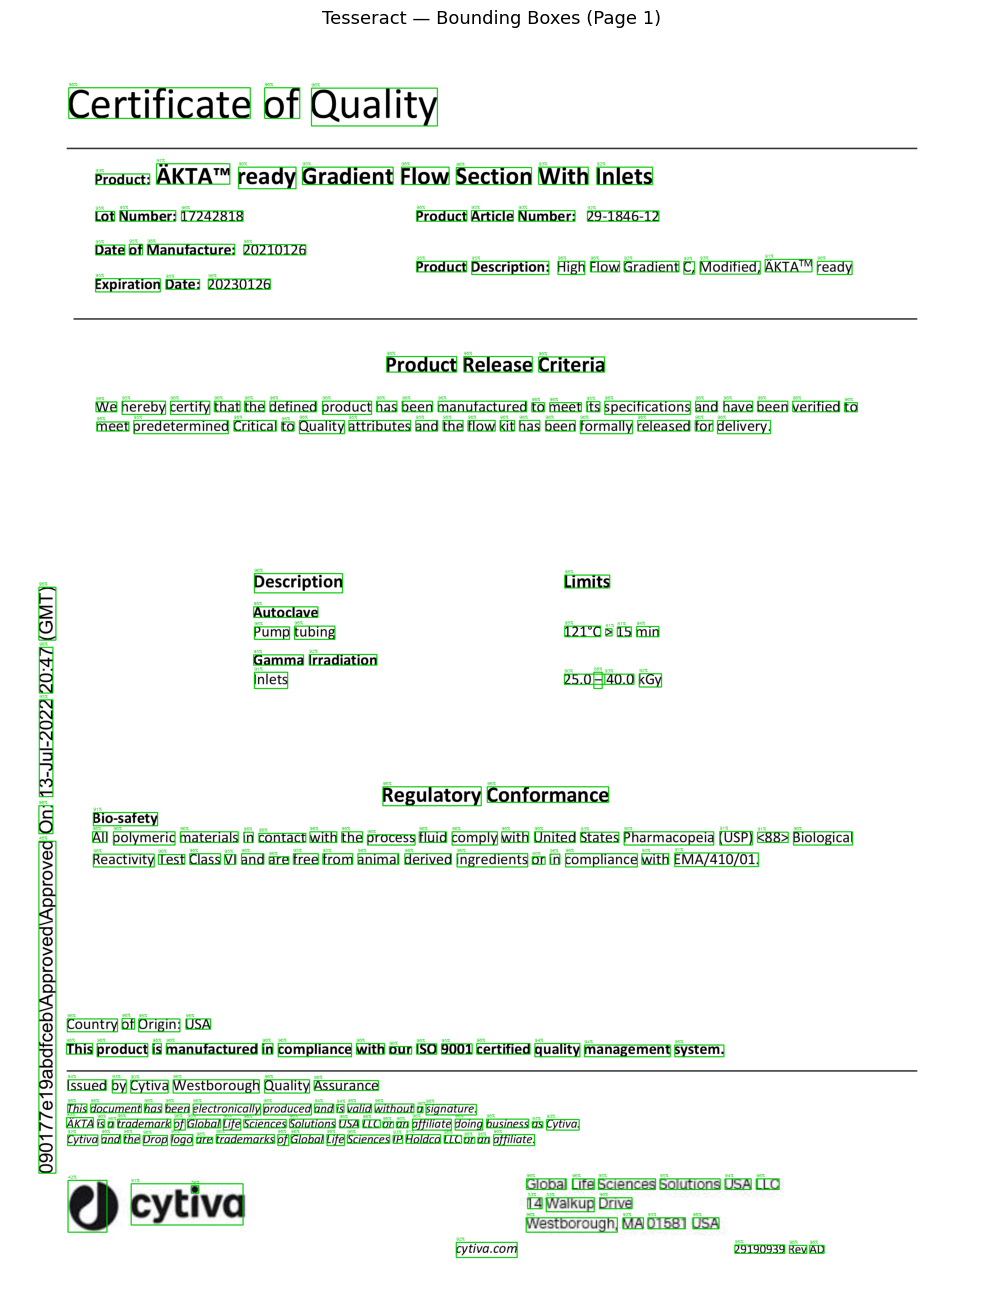

✅ Saved: tesseract_page1_boxes.png

✅ Tesseract complete! Text saved to tesseract_output.txt


In [4]:
# ============================================
# CELL 4: Tesseract OCR
# ============================================
#
# WHAT IS TESSERACT?
#   The oldest and most widely used open-source OCR engine, originally
#   developed by HP and now maintained by Google. It uses pattern-matching
#   rules rather than deep learning.
#
# STRENGTHS:
#   ✅ Very fast
#   ✅ Great for clean, printed text in standard fonts
#   ✅ No internet or GPU required
#
# WEAKNESSES:
#   ❌ Struggles with handwriting, rotated text, or complex layouts
#   ❌ Can jumble column order on multi-column documents
#   ❌ Less accurate on low-res or noisy scans
#
# WHAT THIS CELL DOES:
#   1. Runs Tesseract on each page
#   2. Draws bounding boxes around detected words
#   3. Saves annotated images and raw text for comparison
# ============================================

import pytesseract
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

tesseract_results = []   # will store extracted text per page

for page_num, pil_img in enumerate(images):
    print(f"\n{'='*50}")
    print(f"📄 Tesseract — Page {page_num + 1}")
    print('='*50)

    # --- Extract raw text ---
    # config: --psm 3 = auto page segmentation, --oem 3 = best LSTM engine
    raw_text = pytesseract.image_to_string(pil_img, config="--psm 3 --oem 3")
    tesseract_results.append(raw_text)

    print("\n📝 RAW TEXT OUTPUT:")
    print("-" * 40)
    print(raw_text if raw_text.strip() else "⚠️  No text detected")
    print("-" * 40)

    # --- Draw bounding boxes ---
    # image_to_data returns word-level boxes with confidence scores
    img_cv = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    data = pytesseract.image_to_data(pil_img, output_type=pytesseract.Output.DICT)

    for i, word in enumerate(data["text"]):
        conf = int(data["conf"][i])
        if conf > 40 and word.strip():   # only draw high-confidence words
            x, y, w, h = data["left"][i], data["top"][i], data["width"][i], data["height"][i]
            cv2.rectangle(img_cv, (x, y), (x + w, y + h), (0, 200, 0), 2)
            cv2.putText(img_cv, f"{conf}%", (x, y - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 200, 0), 1)

    # --- Save and display annotated image ---
    out_path = f"tesseract_page{page_num + 1}_boxes.png"
    cv2.imwrite(out_path, img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 13))
    plt.imshow(img_rgb)
    plt.title(f"Tesseract — Bounding Boxes (Page {page_num + 1})", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"tesseract_page{page_num + 1}_annotated.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out_path}")

# --- Save combined text ---
with open("tesseract_output.txt", "w") as f:
    for i, text in enumerate(tesseract_results):
        f.write(f"--- PAGE {i+1} ---\n{text}\n\n")

print("\n✅ Tesseract complete! Text saved to tesseract_output.txt")

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:17<00:00, 225.03it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:02<00:00, 4248.35it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:08<00:00, 239.75it/s]



📄 PaddleOCR — Page 1

📝 RAW TEXT OUTPUT:
----------------------------------------
  [1.00]  Certificate of Quality
  [0.97]  Product: AKTArM ready Gradient Flow Section With Inlets
  [0.99]  Lot Number: 17242818
  [0.99]  Product Article Number: 29-1846-12
  [1.00]  Date of Manufacture: 20210126
  [1.00]  Product Description: High Flow Gradient C, Modified, AKTATM ready
  [0.99]  Expiration Date: 20230126
  [0.98]  Product Release Criteria.
  [0.98]  We hereby certify that the defined product has been manufactured to meet its specifications and have been verified to
  [0.98]  meet predetermined Critical to Quality attributes and the flow kit has been formally released for delivery.
  [1.00]  Description
  [1.00]  Limits
  [0.95]   On: 13-Jul-2022 20:47 (GMT)
  [1.00]  Autoclave
  [0.96]   Pump tubing
  [0.96]  121C >15 min
  [0.96]  Gamma Irradiation.
  [1.00]  Inlets
  [0.97]  25.0- 40.0 kGy
  [1.00]  Regulatory Conformance
  [1.00]  Bio-safety
  [0.99]  All polymeric materials in co

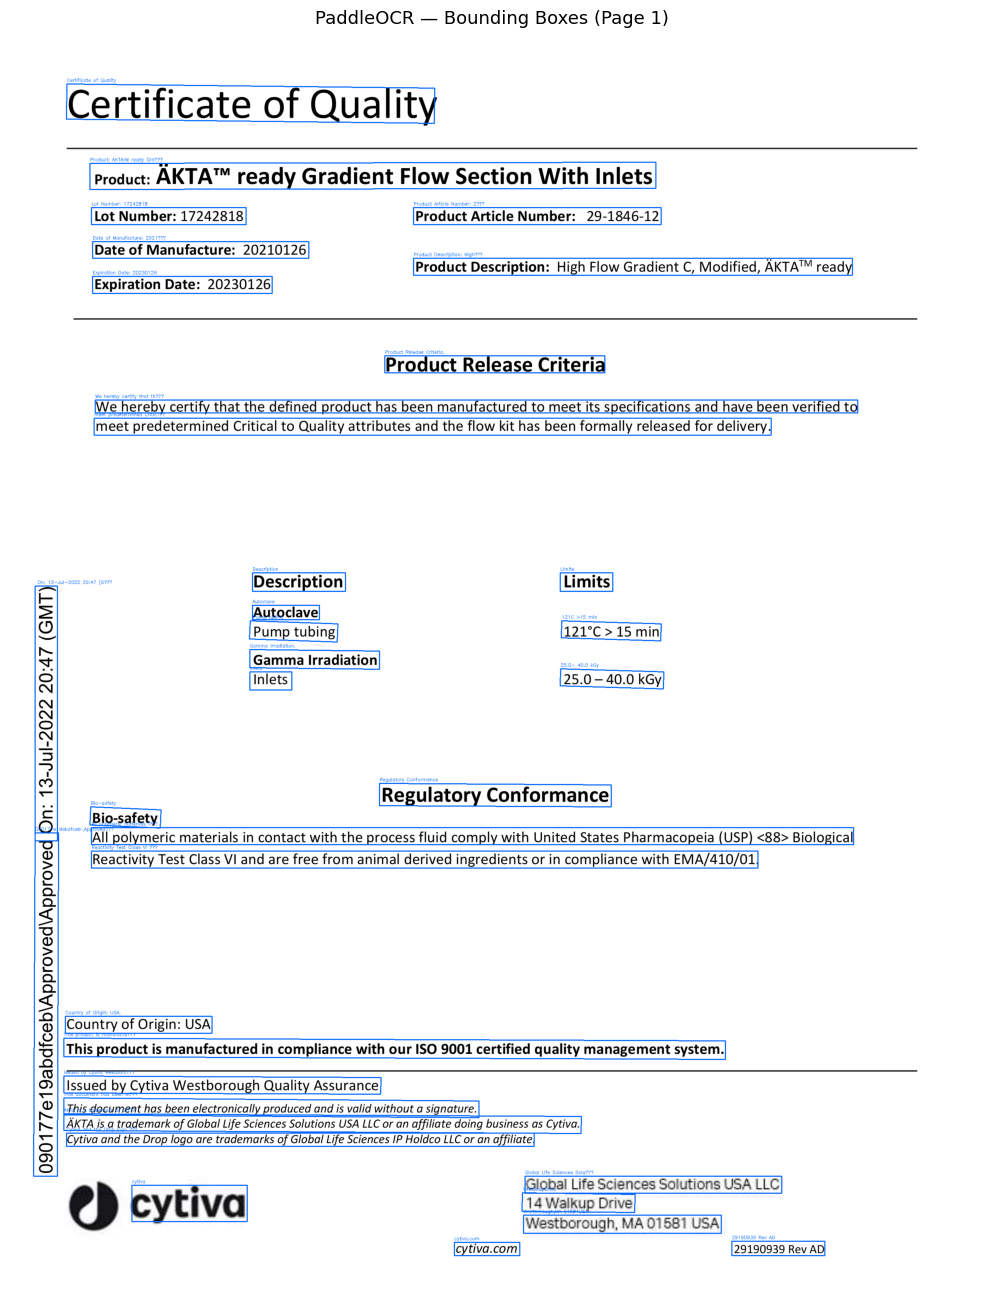

✅ Saved: paddle_page1_boxes.png

✅ PaddleOCR complete! Text saved to paddle_output.txt


In [5]:
# ============================================
# CELL 5: PaddleOCR
# ============================================
#
# WHAT IS PADDLEOCR?
#   A deep learning OCR system built by Baidu on their PaddlePaddle framework.
#   It uses a 3-stage pipeline: text detection → direction classification → recognition.
#
# STRENGTHS:
#   ✅ Excellent at detecting and grouping structured text (tables, labels, forms)
#   ✅ Handles rotated or skewed text well
#   ✅ Returns bounding box coordinates natively
#
# WEAKNESSES:
#   ❌ Slower than Tesseract
#   ❌ First run downloads model weights (~100MB) — needs internet
#   ❌ More complex installation (you already handled this!)
#
# WHAT THIS CELL DOES:
#   1. Runs PaddleOCR on each page
#   2. Draws bounding boxes with detected text labels
#   3. Saves annotated images and raw text
# ============================================

from paddleocr import PaddleOCR
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Initialize once — use_angle_cls=True handles rotated text
# show_log=False keeps output clean
ocr_engine = PaddleOCR(use_angle_cls=True, lang="en", show_log=False)

paddle_results = []   # store extracted text per page

for page_num, pil_img in enumerate(images):
    print(f"\n{'='*50}")
    print(f"📄 PaddleOCR — Page {page_num + 1}")
    print('='*50)

    img_array = np.array(pil_img)   # PaddleOCR expects a numpy array

    # --- Run OCR ---
    result = ocr_engine.ocr(img_array, cls=True)

    # --- Extract and display text ---
    # result structure: [ [ [box_coords], (text, confidence) ], ... ]
    page_text_lines = []
    print("\n📝 RAW TEXT OUTPUT:")
    print("-" * 40)

    if result and result[0]:
        for line in result[0]:
            box = line[0]                    # 4 corner coordinates
            text, confidence = line[1]       # detected text + confidence score
            page_text_lines.append(text)
            print(f"  [{confidence:.2f}]  {text}")
    else:
        print("⚠️  No text detected on this page")

    print("-" * 40)
    paddle_results.append("\n".join(page_text_lines))

    # --- Draw bounding boxes ---
    img_cv = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

    if result and result[0]:
        for line in result[0]:
            box = np.array(line[0], dtype=np.int32)
            text, conf = line[1]
            cv2.polylines(img_cv, [box], isClosed=True, color=(255, 100, 0), thickness=2)
            # Label each box with its text (truncated if long)
            label = text[:25] + "…" if len(text) > 25 else text
            cv2.putText(img_cv, label, (box[0][0], box[0][1] - 6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 0), 1)

    # --- Save and display ---
    out_path = f"paddle_page{page_num + 1}_boxes.png"
    cv2.imwrite(out_path, img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 13))
    plt.imshow(img_rgb)
    plt.title(f"PaddleOCR — Bounding Boxes (Page {page_num + 1})", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"paddle_page{page_num + 1}_annotated.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out_path}")

# --- Save combined text ---
with open("paddle_output.txt", "w") as f:
    for i, text in enumerate(paddle_results):
        f.write(f"--- PAGE {i+1} ---\n{text}\n\n")

print("\n✅ PaddleOCR complete! Text saved to paddle_output.txt")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete
📄 EasyOCR — Page 1

📝 RAW TEXT OUTPUT:
----------------------------------------
  [0.97]  Certificate of Quality
  [1.00]  Product:
  [0.81]  AKTATm
  [0.87]  ready Gradient Flow Section With Inlets
  [0.67]  Lot Number: 17242818
  [0.84]  Product Article Number:
  [0.98]  29-1846-12
  [0.96]  Date of Manufacture: 20210126
  [0.84]  Product Description: High Flow Gradient C, Modified, AKTATM ready
  [0.96]  Expiration Date: 20230126
  [0.77]  Product Release Criteria
  [0.82]  We hereby certify that the defined product has been manufactured to meet its specifications and have been verified to
  [1.00]  meet
  [0.73]  predetermined Critical to Quality attributes and the flow kit has been formally released for delivery:
  [1.00]  Description
  [1.00]  Limits
  [0.56]  8
  [0.81]  Autoclave
  [0.95]  Pump tubing
  [0.52]  1218C > 15 min
  [0.83]  Gamma Irradiation
  [0.96]  8
  [1.00]  Inlets
  [1.00]  25.0
  [

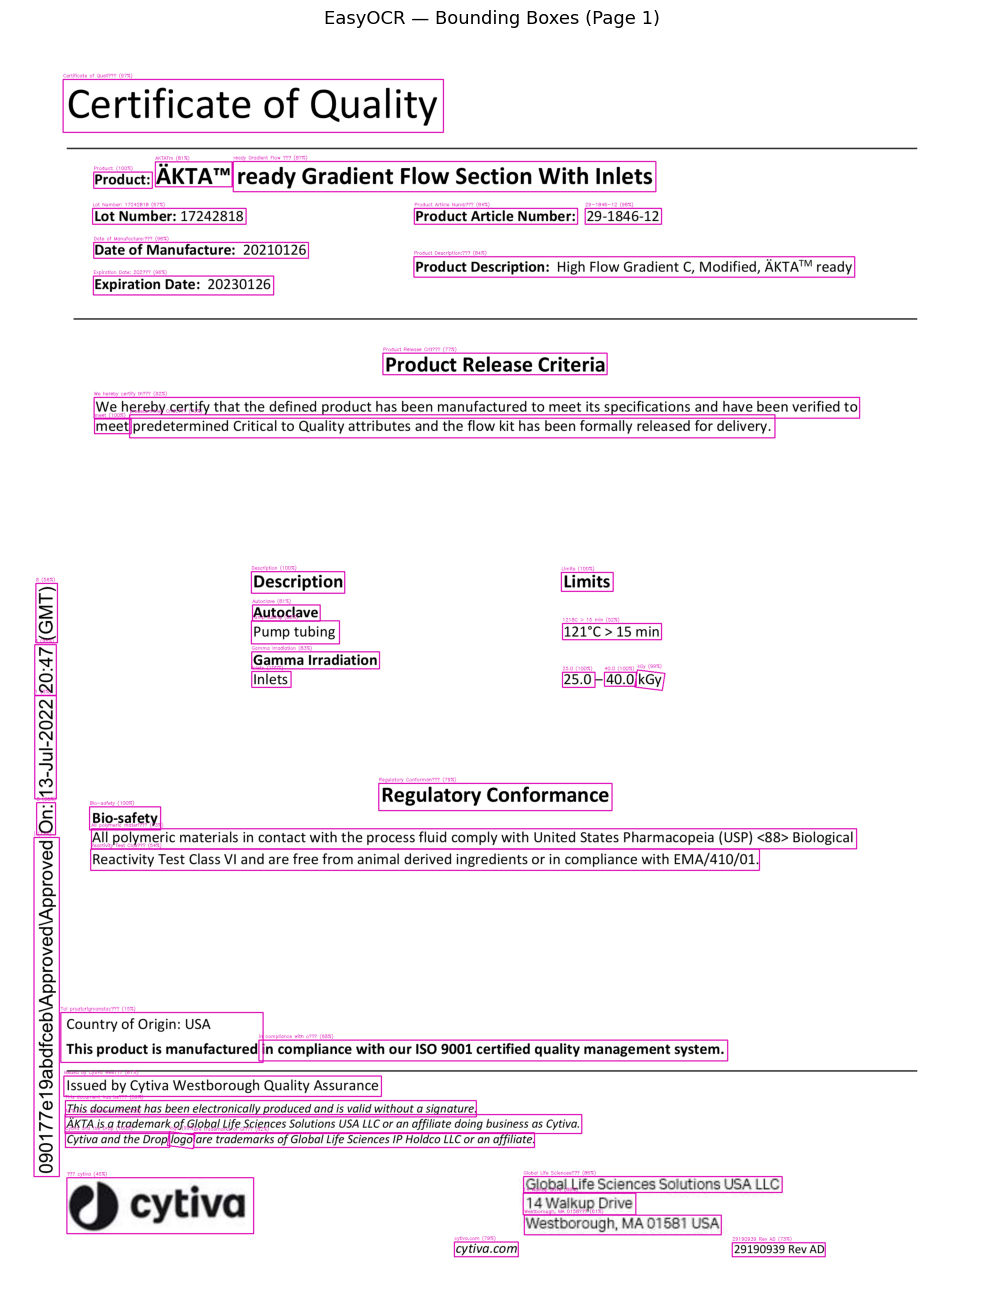

✅ Saved: easyocr_page1_boxes.png

✅ EasyOCR complete! Text saved to easyocr_output.txt


In [6]:
# ============================================
# CELL 6: EasyOCR
# ============================================
#
# WHAT IS EASYOCR?
#   A Python OCR library built on PyTorch, designed to be the simplest
#   deep-learning OCR to use. Supports 80+ languages out of the box.
#
# STRENGTHS:
#   ✅ Extremely easy API (just 2 lines to get results)
#   ✅ Handles varied fonts, stamps, handwriting better than Tesseract
#   ✅ Good with non-standard layouts (e.g., labels, packaging)
#
# WEAKNESSES:
#   ❌ Slowest of the three (especially without GPU)
#   ❌ Can merge or split text blocks unexpectedly
#   ❌ First run downloads model weights (~100MB) — needs internet
#
# WHAT THIS CELL DOES:
#   1. Runs EasyOCR on each page
#   2. Draws bounding boxes with confidence scores
#   3. Saves annotated images and raw text
# ============================================

import easyocr
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Initialize reader — downloads models on first run
# gpu=False works on free Colab; set gpu=True if you have a GPU runtime
reader = easyocr.Reader(["en"], gpu=False)

easyocr_results = []   # store extracted text per page

for page_num, pil_img in enumerate(images):
    print(f"\n{'='*50}")
    print(f"📄 EasyOCR — Page {page_num + 1}")
    print('='*50)

    img_array = np.array(pil_img)

    # --- Run OCR ---
    # Returns: list of (bounding_box, text, confidence)
    result = reader.readtext(img_array)

    # --- Extract and display text ---
    print("\n📝 RAW TEXT OUTPUT:")
    print("-" * 40)
    page_text_lines = []

    if result:
        for (bbox, text, confidence) in result:
            page_text_lines.append(text)
            print(f"  [{confidence:.2f}]  {text}")
    else:
        print("⚠️  No text detected on this page")

    print("-" * 40)
    easyocr_results.append("\n".join(page_text_lines))

    # --- Draw bounding boxes ---
    img_cv = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

    for (bbox, text, confidence) in result:
        # bbox = [[x1,y1],[x2,y2],[x3,y3],[x4,y4]]
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(img_cv, [pts], isClosed=True, color=(180, 0, 220), thickness=2)
        label = f"{text[:20]}… ({confidence:.0%})" if len(text) > 20 else f"{text} ({confidence:.0%})"
        cv2.putText(img_cv, label, (pts[0][0], pts[0][1] - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (180, 0, 220), 1)

    # --- Save and display ---
    out_path = f"easyocr_page{page_num + 1}_boxes.png"
    cv2.imwrite(out_path, img_cv)

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 13))
    plt.imshow(img_rgb)
    plt.title(f"EasyOCR — Bounding Boxes (Page {page_num + 1})", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"easyocr_page{page_num + 1}_annotated.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved: {out_path}")

# --- Save combined text ---
with open("easyocr_output.txt", "w") as f:
    for i, text in enumerate(easyocr_results):
        f.write(f"--- PAGE {i+1} ---\n{text}\n\n")

print("\n✅ EasyOCR complete! Text saved to easyocr_output.txt")